```
flow
1. start (read csv)
2. cleaning (validation, normalisasi, filtering)
3. classifier --> indobert
4. agregat per toko (scoring, ekstraksi problem?)
5. end (to csv)
```

### install & load library

In [ ]:
!pip install -q transformers torch pandas tqdm

import pandas as pd
import numpy as np
import torch
import re
from transformers import pipeline
from tqdm.auto import tqdm
from collections import Counter
from google.colab import drive
drive.mount('/content/drive')
import json

Mounted at /content/drive


In [ ]:
!pip install -q keybert

from keybert import KeyBERT

kw_model = KeyBERT(model='indobenchmark/indobert-base-p2')

In [ ]:
pip install bertopic sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.5 MB/s eta 0:00:00


In [ ]:
# file lama
file_path = '/content/drive/MyDrive/sentiment0_290126.json'

with open(file_path, 'r') as f:
    sentimen_lama = json.load(f)

In [ ]:
df_sentimen_lama = pd.read_json(file_path)
df_sentimen_lama.head()

,place_name,place_lat,place_lng,sector,reviewer_name,rating,time,text,text_clean,sentiment,score
0,Bebek Mas Mun BakauHeni,-5.865811,105.756932,lahan belum dikuasai,Catherine Puspita,5,2 tahun lalu,Bebek enak dan empuk. Bisa dimakan dengan muda...,bebek enak dan empuk bisa dimakan dengan muda...,Positif,0.999970
1,Bebek Mas Mun BakauHeni,-5.865811,105.756932,lahan belum dikuasai,Ernie Arbie,5,sebulan lalu,Favorit bgt bebek mas mun ... Suka bebeknya ya...,favorit banget bebek mas mun suka bebeknya...,Positif,0.999969
2,Bebek Mas Mun BakauHeni,-5.865811,105.756932,lahan belum dikuasai,Mahfut Arifin,5,2 bulan lalu,Makan bebek d sini enak bangett rekomen bebekn...,makan bebek d sini enak bangett bagus bebekny ...,Positif,0.999970
3,Bebek Mas Mun BakauHeni,-5.865811,105.756932,lahan belum dikuasai,BeWee,5,3 tahun lalu,Mantap ada lalapan ayam terjangkau. Ada harga ...,bagus ada lalapan ayam terjangkau ada harga n...,Positif,0.999957
4,Bebek Mas Mun BakauHeni,-5.865811,105.756932,lahan belum dikuasai,Benny Manurung,1,6 bulan lalu,Karyawan nya gak niat jualan....1 jam lebih nu...,karyawan nya tidak niat jualan 1 jam lebih ...,Negatif,0.999872


In [ ]:
# file baru
path_file = '/content/drive/MyDrive/sentimen_zonabaru.csv'
df_sentimen_baru = pd.read_csv(path_file)

df_sentimen_baru

,place_name,sector,reviewer_name,rating,time,text,text_clean,sentiment,score,Zonasi Kawasan
0,Bebek Mas Mun BakauHeni,lahan belum dikuasai,Catherine Puspita,5,2 tahun lalu,Bebek enak dan empuk. Bisa dimakan dengan muda...,bebek enak dan empuk bisa dimakan dengan muda...,Positif,0.999970,Harbourfront and Intermoda Area
1,Bebek Mas Mun BakauHeni,lahan belum dikuasai,Ernie Arbie,5,sebulan lalu,Favorit bgt bebek mas mun ... Suka bebeknya ya...,favorit banget bebek mas mun suka bebeknya...,Positif,0.999969,Harbourfront and Intermoda Area
2,Bebek Mas Mun BakauHeni,lahan belum dikuasai,Mahfut Arifin,5,2 bulan lalu,Makan bebek d sini enak bangett rekomen bebekn...,makan bebek d sini enak bangett bagus bebekny ...,Positif,0.999970,Harbourfront and Intermoda Area
3,Bebek Mas Mun BakauHeni,lahan belum dikuasai,BeWee,5,3 tahun lalu,Mantap ada lalapan ayam terjangkau. Ada harga ...,bagus ada lalapan ayam terjangkau ada harga n...,Positif,0.999957,Harbourfront and Intermoda Area
4,Bebek Mas Mun BakauHeni,lahan belum dikuasai,Benny Manurung,1,6 bulan lalu,Karyawan nya gak niat jualan....1 jam lebih nu...,karyawan nya tidak niat jualan 1 jam lebih ...,Negatif,0.999872,Harbourfront and Intermoda Area
...,...,...,...,...,...,...,...,...,...,...
276,Alfamart lintas bakauheni,lahan belum dikuasai,Muhamad Jazuli,5,5 bulan lalu,"Pegawai nya ramah, tempat nya bersih",pegawai nya ramah tempat nya bersih,Positif,0.999964,di luar area
277,Alfamart lintas bakauheni,lahan belum dikuasai,Luqman,5,2 tahun lalu,اَلْحَمْدُلِلّهِ\nBeli kebutuhan untuk naik kapal,ا ل ح م د ل ل ه \nbeli kebutuhan untuk naik kapal,Netral,0.999888,di luar area
278,Alfamart lintas bakauheni,lahan belum dikuasai,Asram Siregar,5,2 tahun lalu,"24hours, bebas parkir mantap...\nPerhatikan ke...",24hours bebas parkir bagus \nperhatikan keb...,Positif,0.999853,di luar area
279,Alfamart lintas bakauheni,lahan belum dikuasai,Rudi Exist,5,2 tahun lalu,Dengan operasi 24 jam membatu orang yang henda...,dengan operasi 24 jam membatu orang yang henda...,Positif,0.999955,di luar area


In [ ]:
# merge data baru ke data lama
df_coords = df_sentimen_lama[['text', 'place_lat', 'place_lng']]

# 'on=text' artinya mencari teks ulasan yang sama di kedua file
df_final = pd.merge(df_sentimen_baru, df_coords, on='text', how='left')

# Ganti isi 'sector' lama dengan 'Zonasi Kawasan'
df_final['sector'] = df_final['Zonasi Kawasan']
df_final = df_final.drop(columns=['Zonasi Kawasan'])
df_final

,place_name,sector,reviewer_name,rating,time,text,text_clean,sentiment,score,place_lat,place_lng
0,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Catherine Puspita,5,2 tahun lalu,Bebek enak dan empuk. Bisa dimakan dengan muda...,bebek enak dan empuk bisa dimakan dengan muda...,Positif,0.999970,-5.865811,105.756932
1,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Ernie Arbie,5,sebulan lalu,Favorit bgt bebek mas mun ... Suka bebeknya ya...,favorit banget bebek mas mun suka bebeknya...,Positif,0.999969,-5.865811,105.756932
2,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Mahfut Arifin,5,2 bulan lalu,Makan bebek d sini enak bangett rekomen bebekn...,makan bebek d sini enak bangett bagus bebekny ...,Positif,0.999970,-5.865811,105.756932
3,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,BeWee,5,3 tahun lalu,Mantap ada lalapan ayam terjangkau. Ada harga ...,bagus ada lalapan ayam terjangkau ada harga n...,Positif,0.999957,-5.865811,105.756932
4,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Benny Manurung,1,6 bulan lalu,Karyawan nya gak niat jualan....1 jam lebih nu...,karyawan nya tidak niat jualan 1 jam lebih ...,Negatif,0.999872,-5.865811,105.756932
...,...,...,...,...,...,...,...,...,...,...,...
282,Alfamart lintas bakauheni,di luar area,Muhamad Jazuli,5,5 bulan lalu,"Pegawai nya ramah, tempat nya bersih",pegawai nya ramah tempat nya bersih,Positif,0.999964,-5.858546,105.743721
283,Alfamart lintas bakauheni,di luar area,Luqman,5,2 tahun lalu,اَلْحَمْدُلِلّهِ\nBeli kebutuhan untuk naik kapal,ا ل ح م د ل ل ه \nbeli kebutuhan untuk naik kapal,Netral,0.999888,-5.858546,105.743721
284,Alfamart lintas bakauheni,di luar area,Asram Siregar,5,2 tahun lalu,"24hours, bebas parkir mantap...\nPerhatikan ke...",24hours bebas parkir bagus \nperhatikan keb...,Positif,0.999853,-5.858546,105.743721
285,Alfamart lintas bakauheni,di luar area,Rudi Exist,5,2 tahun lalu,Dengan operasi 24 jam membatu orang yang henda...,dengan operasi 24 jam membatu orang yang henda...,Positif,0.999955,-5.858546,105.743721


In [ ]:
# cleaning data di luar area
df_clean = df_final[df_final['sector'] != 'di luar area'].copy()
df_clean = df_clean.dropna(subset=['sector'])
df_clean.to_csv('sentiment_final_clean.csv', index=False)

print(f"Data Berhasil Dibersihkan!")
print(f"Jumlah data awal: {len(df_final)}")
print(f"Jumlah data setelah drop: {len(df_clean)}")
print(f"Sektor yang tersedia sekarang: {df_clean['sector'].unique()}")

display(df_clean.head())

Data Berhasil Dibersihkan!
Jumlah data awal: 287
Jumlah data setelah drop: 247
Sektor yang tersedia sekarang: ['Harbourfront and Intermoda Area' 'Hilltop Resort' 'Marina District']


,place_name,sector,reviewer_name,rating,time,text,text_clean,sentiment,score,place_lat,place_lng
0,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Catherine Puspita,5,2 tahun lalu,Bebek enak dan empuk. Bisa dimakan dengan muda...,bebek enak dan empuk bisa dimakan dengan muda...,Positif,0.999970,-5.865811,105.756932
1,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Ernie Arbie,5,sebulan lalu,Favorit bgt bebek mas mun ... Suka bebeknya ya...,favorit banget bebek mas mun suka bebeknya...,Positif,0.999969,-5.865811,105.756932
2,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Mahfut Arifin,5,2 bulan lalu,Makan bebek d sini enak bangett rekomen bebekn...,makan bebek d sini enak bangett bagus bebekny ...,Positif,0.999970,-5.865811,105.756932
3,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,BeWee,5,3 tahun lalu,Mantap ada lalapan ayam terjangkau. Ada harga ...,bagus ada lalapan ayam terjangkau ada harga n...,Positif,0.999957,-5.865811,105.756932
4,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Benny Manurung,1,6 bulan lalu,Karyawan nya gak niat jualan....1 jam lebih nu...,karyawan nya tidak niat jualan 1 jam lebih ...,Negatif,0.999872,-5.865811,105.756932


In [ ]:
df = df_clean.copy()
df = df[
    ~((df['rating'] >= 3.5) & (df['sentiment'] == 'Negatif')) &
    ~((df['rating'] < 3.5) & (df['sentiment'] == 'Positif'))
]

In [ ]:
df.head()

,place_name,sector,reviewer_name,rating,time,text,text_clean,sentiment,score,place_lat,place_lng
0,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Catherine Puspita,5,2 tahun lalu,Bebek enak dan empuk. Bisa dimakan dengan muda...,bebek enak dan empuk bisa dimakan dengan muda...,Positif,0.999970,-5.865811,105.756932
1,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Ernie Arbie,5,sebulan lalu,Favorit bgt bebek mas mun ... Suka bebeknya ya...,favorit banget bebek mas mun suka bebeknya...,Positif,0.999969,-5.865811,105.756932
2,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Mahfut Arifin,5,2 bulan lalu,Makan bebek d sini enak bangett rekomen bebekn...,makan bebek d sini enak bangett bagus bebekny ...,Positif,0.999970,-5.865811,105.756932
3,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,BeWee,5,3 tahun lalu,Mantap ada lalapan ayam terjangkau. Ada harga ...,bagus ada lalapan ayam terjangkau ada harga n...,Positif,0.999957,-5.865811,105.756932
4,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Benny Manurung,1,6 bulan lalu,Karyawan nya gak niat jualan....1 jam lebih nu...,karyawan nya tidak niat jualan 1 jam lebih ...,Negatif,0.999872,-5.865811,105.756932


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 227 entries, 0 to 246
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   place_name     227 non-null    object 
 1   sector         227 non-null    object 
 2   reviewer_name  227 non-null    object 
 3   rating         227 non-null    int64  
 4   time           227 non-null    object 
 5   text           227 non-null    object 
 6   text_clean     227 non-null    object 
 7   sentiment      227 non-null    object 
 8   score          227 non-null    float64
 9   place_lat      227 non-null    float64
 10  place_lng      227 non-null    float64
dtypes: float64(3), int64(1), object(7)
memory usage: 21.3+ KB


In [ ]:
empty_rows = df[df['text_clean'].str.strip() == ""].shape[0]
print(f"jumlah baris string kosong: {empty_rows}")

jumlah baris string kosong: 31


In [ ]:
df['text_clean'] = df['text_clean'].replace(r'^\s*$', np.nan, regex=True)
df = df.dropna(subset=['text_clean'])
df = df.reset_index(drop=True)
print(f"jumlah baris setelah dibersihkan: {len(df)}")

jumlah baris setelah dibersihkan: 281


### sentiment analyst

In [ ]:
# load model
device = 0 if torch.cuda.is_available() else -1
classifier = pipeline("text-classification",
                      model="crypter70/IndoBERT-Sentiment-Analysis",
                      device=device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
# proses df
texts = df['text_clean'].tolist()
results = []

for out in tqdm(classifier(texts, batch_size=32), total=len(texts)):
    results.append(out)

# mapping label
mapping_label = {"NEUTRAL": "Netral", "POSITIVE": "Positif", "NEGATIVE": "Negatif"}
df['sentiment'] = [mapping_label.get(x['label'].upper(), x['label'].upper()) for x in results]
df['score'] = [x['score'] for x in results]

  0%|          | 0/281 [00:00<?, ?it/s]

In [ ]:
df

,place_name,sector,reviewer_name,rating,time,text,text_clean,sentiment,score,place_lat,place_lng
0,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Catherine Puspita,5,2 tahun lalu,Bebek enak dan empuk. Bisa dimakan dengan muda...,bebek enak dan empuk bisa dimakan dengan muda...,Positif,0.999970,-5.865811,105.756932
1,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Ernie Arbie,5,sebulan lalu,Favorit bgt bebek mas mun ... Suka bebeknya ya...,favorit banget bebek mas mun suka bebeknya...,Positif,0.999969,-5.865811,105.756932
2,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Mahfut Arifin,5,2 bulan lalu,Makan bebek d sini enak bangett rekomen bebekn...,makan bebek d sini enak bangett bagus bebekny ...,Positif,0.999970,-5.865811,105.756932
3,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,BeWee,5,3 tahun lalu,Mantap ada lalapan ayam terjangkau. Ada harga ...,bagus ada lalapan ayam terjangkau ada harga n...,Positif,0.999957,-5.865811,105.756932
4,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Benny Manurung,1,6 bulan lalu,Karyawan nya gak niat jualan....1 jam lebih nu...,karyawan nya tidak niat jualan 1 jam lebih ...,Negatif,0.999872,-5.865811,105.756932
...,...,...,...,...,...,...,...,...,...,...,...
242,SRC TOKO AYU BAKAUHENI,Marina District,Asnawi Walet,5,9 bulan lalu,Semoga sukses,semoga sukses,Positif,0.999944,-5.867434,105.745075
243,SRC TOKO AYU BAKAUHENI,Marina District,Asnawi Walet,5,9 bulan lalu,Semoga sukses,semoga sukses,Positif,0.999944,-5.867434,105.745075
244,SRC TOKO AYU BAKAUHENI,Marina District,asnawi ilyas,5,setahun lalu,Semoga sukses,semoga sukses,Positif,0.999944,-5.867434,105.745075
245,SRC TOKO AYU BAKAUHENI,Marina District,asnawi ilyas,5,setahun lalu,Semoga sukses,semoga sukses,Positif,0.999944,-5.867434,105.745075


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
Positif,170
Netral,31
Negatif,26


In [ ]:
df.to_json('1final_sentiment.json', orient='records', indent=4, force_ascii=False)

print("File JSON sudah siap!")

File JSON sudah siap!


## extract topic

In [ ]:
stop_words_id = [
    # --- Kata Umum Bahasa Indonesia ---
    'yang', 'dan', 'di', 'ke', 'dari', 'pada', 'dalam', 'dengan', 'untuk', 'adalah',
    'itu', 'ini', 'saya', 'kami', 'kita', 'anda', 'dia', 'mereka', 'apa', 'mana',
    'siapa', 'kapan', 'mengapa', 'bagaimana', 'bisa', 'boleh', 'ada', 'tidak', 'tak',
    'jangan', 'sudah', 'telah', 'sedang', 'akan', 'juga', 'saja', 'hanya', 'cuma',
    'tetapi', 'tapi', 'namun', 'karena', 'kalau', 'jika', 'seperti', 'bagi', 'serta',

    # --- Kata Keterangan & Penanda ---
    'sangat', 'sekali', 'banget', 'bgt', 'amat', 'terlalu', 'begitu', 'cukup',
    'lagi', 'tadi', 'nanti', 'besok', 'kemarin', 'sekarang', 'skrg', 'dulu',
    'baru', 'lama', 'bentar', 'sebentar', 'jam', 'menit', 'hari', 'bulan', 'tahun',

    # --- Singkatan & Slang (Banyak muncul di review) ---
    'yg', 'dg', 'dgn', 'klo', 'kl', 'kalo', 'udh', 'sudah', 'sdh', 'udah', 'gak',
    'ga', 'gk', 'aja', 'aj', 'jd', 'jadi', 'krn', 'karna', 'utk', 'untuk', 'pas',
    'nih', 'tuh', 'loh', 'kok', 'deh', 'lah', 'sih', 'kan', 'dong', 'yah', 'ya',
    'd', 'ke', 'pd', 'sama', 'ama', 'biar', 'buat', 'biarpun', 'dr', 'drpd',

    # --- Kata Sifat Umum (Sering jadi noise di ekstraksi topik) ---
    'bagus', 'mantap', 'mantab', 'oke', 'ok', 'mantul', 'keren', 'enak', 'favorit',
    'nyaman', 'bersih', 'ramah', 'cepat', 'lancar', 'murah', 'mahal', 'lumayan',
    'lumayanlah', 'best', 'semoga', 'sukses', 'lancar', 'jaya', 'sip',

    # --- Nama Tempat & Entitas Konteks (Opsional, agar topik lebih spesifik) ---
    'bakauheni', 'merak', 'lampung', 'pelabuhan', 'dermaga', 'kapal', 'ferry',
    'terminal', 'eksekutif', 'executive', 'mas', 'mun', 'toko', 'ayu', 'rm',
    'daerah', 'tempat', 'lokasi', 'area', 'sektor', 'district'
]

In [ ]:
def extract_topics(text):
    if not text or len(str(text)) < 5:
        return ""

    keywords = kw_model.extract_keywords(
        str(text),
        keyphrase_ngram_range=(1, 3),
        stop_words=stop_words_id,
        top_n=3
    )
    return ", ".join([k[0] for k in keywords])

df['topic'] = df['text_clean'].apply(extract_topics)
display(df[['text_clean', 'topic']].head())

,text_clean,topic
0,bebek enak dan empuk bisa dimakan dengan muda...,"bebek empuk dimakan, nya telur dadarnya, telur..."
1,favorit banget bebek mas mun suka bebeknya...,"bebeknya lembut gurih, suka bebeknya lembut, p..."
2,makan bebek d sini enak bangett bagus bebekny ...,"bumbuny meresap bgtt, bangett bebekny empuk, b..."
3,bagus ada lalapan ayam terjangkau ada harga n...,"goreng panas sambel, ayam terjangkau harga, ay..."
4,karyawan nya tidak niat jualan 1 jam lebih ...,"jualan lebih nunggu, karyawan nya niat, nya ni..."


## agregat lokasi

In [ ]:
df

,place_name,sector,reviewer_name,rating,time,text,text_clean,sentiment,score,place_lat,place_lng,topic
0,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Catherine Puspita,5,2 tahun lalu,Bebek enak dan empuk. Bisa dimakan dengan muda...,bebek enak dan empuk bisa dimakan dengan muda...,Positif,0.999970,-5.865811,105.756932,"bebek empuk dimakan, nya telur dadarnya, telur..."
1,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Ernie Arbie,5,sebulan lalu,Favorit bgt bebek mas mun ... Suka bebeknya ya...,favorit banget bebek mas mun suka bebeknya...,Positif,0.999969,-5.865811,105.756932,"bebeknya lembut gurih, suka bebeknya lembut, p..."
2,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Mahfut Arifin,5,2 bulan lalu,Makan bebek d sini enak bangett rekomen bebekn...,makan bebek d sini enak bangett bagus bebekny ...,Positif,0.999970,-5.865811,105.756932,"bumbuny meresap bgtt, bangett bebekny empuk, b..."
3,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,BeWee,5,3 tahun lalu,Mantap ada lalapan ayam terjangkau. Ada harga ...,bagus ada lalapan ayam terjangkau ada harga n...,Positif,0.999957,-5.865811,105.756932,"goreng panas sambel, ayam terjangkau harga, ay..."
4,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,Benny Manurung,1,6 bulan lalu,Karyawan nya gak niat jualan....1 jam lebih nu...,karyawan nya tidak niat jualan 1 jam lebih ...,Negatif,0.999872,-5.865811,105.756932,"jualan lebih nunggu, karyawan nya niat, nya ni..."
...,...,...,...,...,...,...,...,...,...,...,...,...
242,SRC TOKO AYU BAKAUHENI,Marina District,Asnawi Walet,5,9 bulan lalu,Semoga sukses,semoga sukses,Positif,0.999944,-5.867434,105.745075,
243,SRC TOKO AYU BAKAUHENI,Marina District,Asnawi Walet,5,9 bulan lalu,Semoga sukses,semoga sukses,Positif,0.999944,-5.867434,105.745075,
244,SRC TOKO AYU BAKAUHENI,Marina District,asnawi ilyas,5,setahun lalu,Semoga sukses,semoga sukses,Positif,0.999944,-5.867434,105.745075,
245,SRC TOKO AYU BAKAUHENI,Marina District,asnawi ilyas,5,setahun lalu,Semoga sukses,semoga sukses,Positif,0.999944,-5.867434,105.745075,


In [ ]:
import pandas as pd

# 1. Load data
df_raw = df.copy()

# 2. Agregasi per Lokasi dan Sektor
# Kita masukkan 'sector' ke dalam index agar tetap muncul di hasil akhir
df_lokasi_sektor = df_raw.pivot_table(
    index=['place_name', 'sector'],
    columns='sentiment',
    aggfunc='size',
    fill_value=0
).reset_index()

# 3. Hitung Total Ulasan per lokasi
df_lokasi_sektor['total_ulasan'] = (
    df_lokasi_sektor['Positif'] +
    df_lokasi_sektor['Negatif'] +
    df_lokasi_sektor['Netral']
)

# 4. Urutkan berdasarkan Sektor dan jumlah ulasan terbanyak
df_lokasi_sektor = df_lokasi_sektor.sort_values(by=['sector', 'total_ulasan'], ascending=[True, False])

# Tampilkan hasil
print("--- AGREGASI SENTIMEN PER LOKASI & SEKTOR ---")
display(df_lokasi_sektor)

# 5. Simpan ke JSON
df_lokasi_sektor.to_json("1final_aggregate_loc.json", orient='records', indent=4)

--- AGREGASI SENTIMEN PER LOKASI & SEKTOR ---


sentiment,place_name,sector,Negatif,Netral,Positif,total_ulasan
4,Anjungan Agung Mall,Harbourfront and Intermoda Area,1,0,9,10
15,Dermaga 5 Pelabuhan Bakauheni,Harbourfront and Intermoda Area,2,2,6,10
22,Masjid Pelabuhan Bakauheni,Harbourfront and Intermoda Area,0,2,8,10
27,Pelabuhan Bakauheni Lampung,Harbourfront and Intermoda Area,4,1,5,10
31,Terminal Executive Bakauheni,Harbourfront and Intermoda Area,2,0,8,10
13,Dermaga 1 Ferry Pelabuhan Bakauheni,Harbourfront and Intermoda Area,0,1,8,9
14,Dermaga 3 Pelabuhan Bakauheni,Harbourfront and Intermoda Area,0,3,6,9
6,Bakauheni Shopping Mall,Harbourfront and Intermoda Area,1,0,7,8
7,Bebek Mas Mun BakauHeni,Harbourfront and Intermoda Area,1,0,7,8
11,DERMAGA 2 Pelabuhan Bakauheni,Harbourfront and Intermoda Area,0,3,5,8


In [ ]:
# 4. Export ke JSON yang lebih rapi
df_final.to_json("final_summary.json", orient='records', indent=4)

In [ ]:
# 4. Export ke JSON yang lebih rapi
df_final_clean.to_json("data_analisis_final_clean.json", orient='records', indent=4)

## count

In [ ]:
# count word from topic

from collections import Counter
import pandas as pd

def get_top_topics_with_counts(series, n=5):
    # Gabungkan semua topik, pecah berdasarkan koma, dan bersihkan spasi
    all_text = ", ".join(series.astype(str))
    phrases = [p.strip() for p in all_text.split(',') if len(p.strip()) > 2]

    counts = Counter(phrases).most_common(n)

    return ", ".join([f"{topic} ({count})" for topic, count in counts])

df_agregasi = df.groupby(['sector', 'sentiment']).agg(
    jumlah_ulasan=('text_clean', 'count'),
    topik_dan_jumlah=('topic', lambda x: get_top_topics_with_counts(x, 5))
).reset_index()

df_all_sector = df.groupby('sentiment').agg(
    jumlah_ulasan=('text_clean', 'count'),
    topik_dan_jumlah=('topic', lambda x: get_top_topics_with_counts(x, 5))
).reset_index()
df_all_sector['sector'] = 'ALL SECTOR'


df_final = pd.concat([df_agregasi, df_all_sector], ignore_index=True)

df_final = df_final.sort_values(['sector', 'sentiment'], ascending=[True, False])

print("--- TABEL AGREGASI SEKTOR, SENTIMEN, & TOPIK ---")
display(df_final)

--- TABEL AGREGASI SEKTOR, SENTIMEN, & TOPIK ---


,sector,sentiment,jumlah_ulasan,topik_dan_jumlah
9,ALL SECTOR,Positif,170,"membantu (5), tempatnya luas (3), pelayananany..."
8,ALL SECTOR,Netral,31,"pulkam nugas kuliah (1), nugas kuliah disini (..."
7,ALL SECTOR,Negatif,26,"pelayanannya minus tolong (4), reguler pelayan..."
2,Harbourfront and Intermoda Area,Positif,105,"membantu (5), tempatnya luas (3), pelayananany..."
1,Harbourfront and Intermoda Area,Netral,23,"pulkam nugas kuliah (1), nugas kuliah disini (..."
0,Harbourfront and Intermoda Area,Negatif,21,"pelayanannya minus tolong (4), reguler pelayan..."
5,Hilltop Resort,Positif,53,"parkir jalan utama (1), mobil parkir jalan (1)..."
4,Hilltop Resort,Netral,8,"membeli berbagai kebutuhan (1), perjalanan mem..."
3,Hilltop Resort,Negatif,5,"ramai perbekalan penyebrangan (1), berdatangan..."
6,Marina District,Positif,12,"gurme bakar nya (1), ayam bakar bekakak (1), b..."


In [ ]:
import json

# 1. Load data dari file data_per_lahan.json
with open('data_per_lahan.json', 'r') as f:
    data_input = json.load(f)

final_aggregated = []

for sector, sentiments in data_input.items():
    # Inisialisasi pengumpul data untuk level Sektor
    combined_topics_list = []
    combined_recs_list = []
    total_ulasan = 0
    sentiment_details = []

    for item in sentiments:
        total_ulasan += item['jumlah_ulasan']

        # Ambil topik dan rekomendasi untuk digabung ke luar
        combined_topics_list.append(f"({item['sentiment']}): {item['topik_dan_jumlah']}")
        combined_recs_list.append(f"SENTIMEN {item['sentiment'].upper()}:\n{item['rekomendasi_ai']}")

        # Simpan detail teknis tetap di dalam sentimen sesuai permintaan
        sentiment_details.append({
            "sentiment": item['sentiment'],
            "jumlah_ulasan": item['jumlah_ulasan'],
            "top_topics": item['top_topics'],
            "topic_counts": item['topic_counts']
        })

    # 2. Susun struktur Flat sesuai permintaan
    entry = {
        "sector": sector,
        "total_ulasan": total_ulasan,
        # Topik dan Rekomendasi ditarik ke level Sektor (di luar sentimen)
        "all_topik_dan_jumlah": " | ".join(combined_topics_list),
        "rekomendasi_komprehensif": "\n\n---\n\n".join(combined_recs_list),
        # Detail teknis tetap di dalam
        "sentiment_breakdown": sentiment_details
    }

    final_aggregated.append(entry)

# 3. Simpan dan Download
with open('data_final_agregat_sektor.json', 'w') as f:
    json.dump(final_aggregated, f, indent=4)

from google.colab import files
files.download('data_final_agregat_sektor.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## split string ke topik dan jumlah

In [ ]:
# split data dari topik dan jumlah ke top_topics and topic_counts

def split_topic_data(val):
    if pd.isna(val):
        return None, None

    topics = [t.split('(')[0].strip() for t in val.split(',')]
    # Mencari semua angka di dalam kurung
    counts = [c.split('(')[1].replace(')', '').strip() for c in val.split(',')]

    return ", ".join(topics), ", ".join(counts)

df_final[['top_topics', 'topic_counts']] = df_final['topik_dan_jumlah'].apply(
    lambda x: pd.Series(split_topic_data(x))
)

cols = ['sector', 'sentiment', 'jumlah_ulasan', 'topik_dan_jumlah', 'top_topics', 'topic_counts']
df_final = df_final[cols]


In [ ]:
df_final

,sector,sentiment,jumlah_ulasan,topik_dan_jumlah,top_topics,topic_counts
9,ALL SECTOR,Positif,170,"membantu (5), tempatnya luas (3), pelayananany...","membantu, tempatnya luas, pelayanananya tempat...","5, 3, 2, 1, 1"
8,ALL SECTOR,Netral,31,"pulkam nugas kuliah (1), nugas kuliah disini (...","pulkam nugas kuliah, nugas kuliah disini, pulk...","1, 1, 1, 1, 1"
7,ALL SECTOR,Negatif,26,"pelayanannya minus tolong (4), reguler pelayan...","pelayanannya minus tolong, reguler pelayananny...","4, 4, 4, 1, 1"
2,Harbourfront and Intermoda Area,Positif,105,"membantu (5), tempatnya luas (3), pelayananany...","membantu, tempatnya luas, pelayanananya tempat...","5, 3, 2, 1, 1"
1,Harbourfront and Intermoda Area,Netral,23,"pulkam nugas kuliah (1), nugas kuliah disini (...","pulkam nugas kuliah, nugas kuliah disini, pulk...","1, 1, 1, 1, 1"
0,Harbourfront and Intermoda Area,Negatif,21,"pelayanannya minus tolong (4), reguler pelayan...","pelayanannya minus tolong, reguler pelayananny...","4, 4, 4, 1, 1"
5,Hilltop Resort,Positif,53,"parkir jalan utama (1), mobil parkir jalan (1)...","parkir jalan utama, mobil parkir jalan, parkir...","1, 1, 1, 1, 1"
4,Hilltop Resort,Netral,8,"membeli berbagai kebutuhan (1), perjalanan mem...","membeli berbagai kebutuhan, perjalanan membeli...","1, 1, 1, 1, 1"
3,Hilltop Resort,Negatif,5,"ramai perbekalan penyebrangan (1), berdatangan...","ramai perbekalan penyebrangan, berdatangan ram...","1, 1, 1, 1, 1"
6,Marina District,Positif,12,"gurme bakar nya (1), ayam bakar bekakak (1), b...","gurme bakar nya, ayam bakar bekakak, bakar nya...","1, 1, 1, 1, 1"


In [ ]:
# ubah struktur
import json

data = df_final.to_dict(orient='records')

structured_data = {}

for item in data:
    sec = item['sector']

    if sec not in structured_data:
        structured_data[sec] = {
            "sector": sec,
            "total_ulasan": 0,
            "all_topik_dan_jumlah_list": [],
            "sentiment_breakdown": []
        }

    jml = int(item['jumlah_ulasan']) if item['jumlah_ulasan'] else 0
    structured_data[sec]["total_ulasan"] += jml

    if item['topik_dan_jumlah']:
        structured_data[sec]["all_topik_dan_jumlah_list"].append(str(item['topik_dan_jumlah']))

    structured_data[sec]["sentiment_breakdown"].append({
        "sentiment": item['sentiment'],
        "jumlah_ulasan": jml,
        "top_topics": item['top_topics'],
        "topic_counts": item['topic_counts']
    })

final_output = []
for sec_data in structured_data.values():
    final_output.append({
        "sector": sec_data["sector"],
        "total_ulasan": sec_data["total_ulasan"],
        "all_topik_dan_jumlah": ", ".join(sec_data["all_topik_dan_jumlah_list"]),
        "sentiment_breakdown": sec_data["sentiment_breakdown"]
    })

with open('1final_summary.json', 'w') as f:
    json.dump(final_output, f, indent=4)

In [ ]:
pd.read_json('1final_summary.json')

,sector,total_ulasan,all_topik_dan_jumlah,sentiment_breakdown
0,ALL SECTOR,227,"membantu (5), tempatnya luas (3), pelayananany...","[{'sentiment': 'Positif', 'jumlah_ulasan': 170..."
1,Harbourfront and Intermoda Area,149,"membantu (5), tempatnya luas (3), pelayananany...","[{'sentiment': 'Positif', 'jumlah_ulasan': 105..."
2,Hilltop Resort,66,"parkir jalan utama (1), mobil parkir jalan (1)...","[{'sentiment': 'Positif', 'jumlah_ulasan': 53,..."
3,Marina District,12,"gurme bakar nya (1), ayam bakar bekakak (1), b...","[{'sentiment': 'Positif', 'jumlah_ulasan': 12,..."


## rekomendasi AI

In [ ]:
!pip install groq

import os
import pandas as pd
from groq import Groq
from google.colab import userdata

# Inisialisasi Client Groq menggunakan Secrets Colab
client = Groq(api_key=userdata.get('GROQ_API_KEY'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 6.1 MB/s eta 0:00:00


### per sektor

In [ ]:
def generate_rekomendasi_groq(sector_name, total, topics, breakdown):
    # Prompt tetap sama karena instruksinya sudah standar profesional
    prompt = f"""
    Anda adalah konsultan bisnis profesional.
    Berdasarkan data berikut, berikan 2-3 rekomendasi strategis singkat untuk sektor ini.

    Nama Sektor: {sector_name}
    Total Ulasan: {total}
    Topik Utama: {topics}
    Detail Sentimen: {breakdown}

    Berdasarkan data di atas, buatlah satu paragraf kesimpulan (maksimal 150 kata) yang mencakup:
    Analisis masalah utama (dari sisi negatif/netral), peluang strategis yang bisa dikembangkan (dari sisi positif), serta rekomendasi tindakan konkret untuk meningkatkan kepuasan pengunjung.

    Gunakan Bahasa Indonesia profesional, lugas, dan pastikan hasilnya hanya terdiri dari SATU paragraf saja.
    """

    chat_completion = client.chat.completions.create(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="llama-3.3-70b-versatile",
        temperature=0.5,
    )
    return chat_completion.choices[0].message.content

In [ ]:
for item in final_output:
    print(f"Mengolah Rekomendasi Groq untuk: {item['sector']}...")

    # Memasukkan argumen yang sesuai ke fungsi
    rekomendasi = generate_rekomendasi_groq(
        item['sector'],
        item['total_ulasan'],
        item['all_topik_dan_jumlah'],
        json.dumps(item['sentiment_breakdown'], indent=2) # Pakai json.dumps lebih rapi
    )

    item['rekomendasi_ai'] = rekomendasi

# Simpan ke JSON baru
with open('1final_summary_with_recommend.json', 'w') as f:
    json.dump(final_output, f, indent=4)

print("Selesai! File '1final_summary_with_recommend.json' telah dibuat.")

Mengolah Rekomendasi Groq untuk: ALL SECTOR...
Mengolah Rekomendasi Groq untuk: Harbourfront and Intermoda Area...
Mengolah Rekomendasi Groq untuk: Hilltop Resort...
Mengolah Rekomendasi Groq untuk: Marina District...
Selesai! File '1final_summary_with_recommend.json' telah dibuat.


In [ ]:
pd.read_json('1final_summary_with_recommend.json')

,sector,total_ulasan,all_topik_dan_jumlah,sentiment_breakdown,rekomendasi_ai
0,ALL SECTOR,227,"membantu (5), tempatnya luas (3), pelayananany...","[{'sentiment': 'Positif', 'jumlah_ulasan': 170...","Berdasarkan data yang disajikan, terdapat bebe..."
1,Harbourfront and Intermoda Area,149,"membantu (5), tempatnya luas (3), pelayananany...","[{'sentiment': 'Positif', 'jumlah_ulasan': 105...","Berdasarkan data ulasan, terdapat masalah utam..."
2,Hilltop Resort,66,"parkir jalan utama (1), mobil parkir jalan (1)...","[{'sentiment': 'Positif', 'jumlah_ulasan': 53,...","Berdasarkan data ulasan Hilltop Resort, terdap..."
3,Marina District,12,"gurme bakar nya (1), ayam bakar bekakak (1), b...","[{'sentiment': 'Positif', 'jumlah_ulasan': 12,...","Berdasarkan data ulasan Marina District, terli..."


### per sentimen

In [ ]:
def get_final_analysis(row):
    """Fungsi untuk memproses rekomendasi per baris"""
    # Ambil data dari kolom yang tersedia di row
    sector = row['sector']
    sentiment = row['sentiment']

    topics = row['topik_dan_jumlah']

    prompt = f"""
    Sektor: {sector}
    Sentimen: {sentiment}
    Topik Utama: {topics}

    Tugas: Berikan 1 rekomendasi bisnis singkat (maks 1 paragraf) yang spesifik untuk manajemen.
    Jika sentimen positif, berikan saran apresiasi/promosi.
    Jika negatif, berikan solusi perbaikan konkret.
    Bahasa: Indonesia yang profesional.
    """

    try:
        chat_completion = client.chat.completions.create(
            messages=[
                {"role": "system", "content": "Anda adalah konsultan strategis pariwisata."},
                {"role": "user", "content": prompt}
            ],
            model="llama-3.3-70b-versatile",
            temperature=0.3,
        )
        return chat_completion.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {str(e)}"

# Jalankan ulang apply-nya
df_final['rekomendasi_ai'] = df_final.apply(get_final_analysis, axis=1)

print("Analisis Selesai!")
display(df_final[['sector', 'sentiment', 'topik_dan_jumlah', 'rekomendasi_ai']])

Analisis Selesai!


,sector,sentiment,topik_dan_jumlah,rekomendasi_ai
9,ALL SECTOR,Positif,"membantu (5), tempatnya bersih (4), semoga suk...","Dengan sentimen positif yang kuat, saya mereko..."
8,ALL SECTOR,Netral,"pulau jawa (2), pulkam nugas (1), nugas kuliah...",Berdasarkan topik utama yang terkait dengan pa...
7,ALL SECTOR,Negatif,"pelayanannya minus (4), reguler pelayanannya (...","Berdasarkan sentimen negatif yang diberikan, k..."
2,Harbourfront and Intermoda Area,Positif,"membantu (5), tempatnya bersih (3), dermaga ek...",Berdasarkan sentimen positif yang diterima dar...
1,Harbourfront and Intermoda Area,Netral,"pulau jawa (2), pulkam nugas (1), nugas kuliah...",Berdasarkan analisis sektor Harbourfront and I...
0,Harbourfront and Intermoda Area,Negatif,"pelayanannya minus (4), reguler pelayanannya (...","Berdasarkan sentimen negatif yang diterima, ka..."
5,Hilltop Resort,Positif,"masjid bsi (3), view nya (2), indah view (2), ...",Berdasarkan sentimen positif dari pengunjung H...
4,Hilltop Resort,Netral,"membeli berbagai (1), berbagai kebutuhan (1), ...",Berdasarkan analisis sentimen netral terkait H...
3,Hilltop Resort,Negatif,"ramai perbekalan (1), kulkas rusak (1), dekat ...","Berdasarkan sentimen negatif yang disampaikan,..."
6,Marina District,Positif,"semoga sukses (4), sukses (4), semoga (4), bak...",Berdasarkan analisis sentimen positif di Sekto...


In [ ]:
df_final

,sector,sentiment,jumlah_ulasan,topik_dan_jumlah,rekomendasi_ai
9,ALL SECTOR,Positif,181,"membantu (5), tempatnya bersih (4), semoga suk...","Dengan sentimen positif yang kuat, saya mereko..."
8,ALL SECTOR,Netral,31,"pulau jawa (2), pulkam nugas (1), nugas kuliah...",Berdasarkan topik utama yang terkait dengan pa...
7,ALL SECTOR,Negatif,35,"pelayanannya minus (4), reguler pelayanannya (...","Berdasarkan sentimen negatif yang diberikan, k..."
2,Harbourfront and Intermoda Area,Positif,113,"membantu (5), tempatnya bersih (3), dermaga ek...",Berdasarkan sentimen positif yang diterima dar...
1,Harbourfront and Intermoda Area,Netral,23,"pulau jawa (2), pulkam nugas (1), nugas kuliah...",Berdasarkan analisis sektor Harbourfront and I...
0,Harbourfront and Intermoda Area,Negatif,29,"pelayanannya minus (4), reguler pelayanannya (...","Berdasarkan sentimen negatif yang diterima, ka..."
5,Hilltop Resort,Positif,56,"masjid bsi (3), view nya (2), indah view (2), ...",Berdasarkan sentimen positif dari pengunjung H...
4,Hilltop Resort,Netral,8,"membeli berbagai (1), berbagai kebutuhan (1), ...",Berdasarkan analisis sentimen netral terkait H...
3,Hilltop Resort,Negatif,6,"ramai perbekalan (1), kulkas rusak (1), dekat ...","Berdasarkan sentimen negatif yang disampaikan,..."
6,Marina District,Positif,12,"semoga sukses (4), sukses (4), semoga (4), bak...",Berdasarkan analisis sentimen positif di Sekto...


## gak

In [ ]:
!pip -q install stanza

import stanza
import pandas as pd
from collections import Counter

# Download & Load Model Bahasa Indonesia
stanza.download('id')
nlp = stanza.Pipeline('id', processors='tokenize,pos')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 38.8 MB/s eta 0:00:00


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Downloading default packages for language: id (Indonesian) ...


INFO:stanza:Downloaded file to /root/stanza_resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/stanza_resources/resources.json
INFO:stanza:Loading these models for language: id (Indonesian):
| Processor | Package    |
--------------------------
| tokenize  | gsd        |
| mwt       | gsd        |
| pos       | gsd_charlm |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Done loading processors!


In [ ]:
def ekstrak_topik(text):
    if not text or text == "":
        return ""

    doc = nlp(str(text))
    # Ambil hanya kata benda (NOUN) dan kata sifat (ADJ)
    topics = [word.text.lower() for sent in doc.sentences for word in sent.words if word.upos in ['NOUN', 'ADJ']]

    return " ".join(topics)

# Terapkan ke dataframe kamu
df['theme'] = df['text_clean'].apply(ekstrak_topik)

In [ ]:
df

,place_name,place_lat,place_lng,sector,reviewer_name,rating,time,text,text_clean,sentiment,score,topic
0,Bebek Mas Mun BakauHeni,-5.865811,105.756932,lahan belum dikuasai,Catherine Puspita,5,2 tahun lalu,Bebek enak dan empuk. Bisa dimakan dengan muda...,bebek enak dan empuk bisa dimakan dengan muda...,Positif,0.999970,"bebek enak, telur dadarnya, sambel enak"
1,Bebek Mas Mun BakauHeni,-5.865811,105.756932,lahan belum dikuasai,Ernie Arbie,5,sebulan lalu,Favorit bgt bebek mas mun ... Suka bebeknya ya...,favorit banget bebek mas mun suka bebeknya...,Positif,0.999969,"bebeknya lembut, pelayanannya ramah, suka bebe..."
2,Bebek Mas Mun BakauHeni,-5.865811,105.756932,lahan belum dikuasai,Mahfut Arifin,5,2 bulan lalu,Makan bebek d sini enak bangett rekomen bebekn...,makan bebek d sini enak bangett bagus bebekny ...,Positif,0.999970,"bumbuny meresap, bebekny empuk, enak bangett"
3,Bebek Mas Mun BakauHeni,-5.865811,105.756932,lahan belum dikuasai,BeWee,5,3 tahun lalu,Mantap ada lalapan ayam terjangkau. Ada harga ...,bagus ada lalapan ayam terjangkau ada harga n...,Positif,0.999957,"ayam terjangkau, ayam goreng, enak drpd"
4,Bebek Mas Mun BakauHeni,-5.865811,105.756932,lahan belum dikuasai,Benny Manurung,1,6 bulan lalu,Karyawan nya gak niat jualan....1 jam lebih nu...,karyawan nya tidak niat jualan 1 jam lebih ...,Negatif,0.999872,"jualan jam, niat jualan, lebih nunggu"
...,...,...,...,...,...,...,...,...,...,...,...,...
276,Monumen Titik Nol Sumatera,-5.865669,105.750371,lahan belum dikuasai,Allexkotosaiyo “Alex” Pedagang oto,5,4 bulan lalu,sangat menarik,sangat menarik,Positif,0.999962,menarik
277,Monumen Titik Nol Sumatera,-5.865669,105.750371,lahan belum dikuasai,Raditya Piknik95,5,4 tahun lalu,Suasana sangat indah view lautnya istimewa,suasana sangat indah view lautnya istimewa,Positif,0.999966,"suasana indah, indah view, lautnya istimewa"
278,Monumen Titik Nol Sumatera,-5.865669,105.750371,lahan belum dikuasai,M. Faldi,5,setahun lalu,Mau tanya dong harga tiket untuk speda mtor br...,mau tanya dong harga tiket untuk speda mtor be...,Netral,0.999890,"tiket speda, mtor berapa, harga tiket"
279,Monumen Titik Nol Sumatera,-5.865669,105.750371,lahan belum dikuasai,Lis Dahniar Sumalatan,5,2 tahun lalu,Viewnya gak pernah mengecewakan. Semoga selalu...,pemandangan tidak pernah mengecewakan semoga ...,Positif,0.999958,"tidak berubah, ramai tidaknya, selalu terjaga"


In [ ]:
# Kelompokkan topik berdasarkan sektor dan sentimen
df_report = df.groupby(['sector', 'sentiment'])['topic'].apply(lambda x: ', '.join(x)).reset_index()

# Fungsi untuk membersihkan dan menghitung frase yang paling sering muncul
from collections import Counter

def get_top_phrases(text):
    # Pisahkan berdasarkan koma, lalu bersihkan spasi
    phrases = [p.strip() for p in text.split(',') if len(p.strip()) > 2]
    # Ambil 10 frase paling sering muncul
    return Counter(phrases).most_common(10)

df_report['top_phrases'] = df_report['topic'].apply(get_top_phrases)

display(df_report[['sector', 'sentiment', 'top_phrases']])

,sector,sentiment,top_phrases
0,lahan belum dikuasai,Negatif,"[(kasir nya, 2), (tapi kapalnya, 2), (banget j..."
1,lahan belum dikuasai,Netral,"[(pelabuhan merak, 4), (naik kapal, 3), (bakau..."
2,lahan belum dikuasai,Positif,"[(pelabuhan bakauheni, 14), (bersih, 6), (sang..."
3,lahan pemprov,Negatif,"[(harga nya, 2), (nya enak, 1), (makan nya, 1)..."
4,lahan pemprov,Netral,"[(makanan lumyan, 1), (makan nasi, 1), (nasi i..."
5,lahan pemprov,Positif,"[(pelabuhan bakauheni, 1), (bakauheni menuju, ..."


In [ ]:
df_wc_input = df.groupby(['sector', 'sentiment'])['theme'].apply(lambda x: ' '.join(str(i) for i in x)).reset_index()

In [ ]:
df_wc_input

,sector,sentiment,theme
0,lahan belum dikuasai,Negatif,karyawan jam nasi makana tempat bersih ayam ku...
1,lahan belum dikuasai,Netral,nugas kuliah disini wkwk meeting point perjala...
2,lahan belum dikuasai,Positif,bebek enak empuk mudah sendok garpu sambel ena...
3,lahan pemprov,Negatif,sebenar rumah makan enak nyaman tukang parkir ...
4,lahan pemprov,Netral,direst area harga makanan nasi ikan kembung
5,lahan pemprov,Positif,jalan raya bakauheni posisi pinggir jalan raya...


In [ ]:
from collections import Counter

def hitung_kata(txt):
    return Counter(txt.split()).most_common(20)

df_wc_input['top_words'] = df_wc_input['theme'].apply(hitung_kata)
display(df_wc_input[['sector', 'sentiment', 'top_words']])

,sector,sentiment,top_words
0,lahan belum dikuasai,Negatif,"[(kapal, 26), (pelayanan, 19), (jam, 14), (tem..."
1,lahan belum dikuasai,Netral,"[(pelabuhan, 14), (kapal, 9), (tiket, 6), (bak..."
2,lahan belum dikuasai,Positif,"[(kapal, 89), (pelabuhan, 80), (tempat, 63), (..."
3,lahan pemprov,Negatif,"[(nasi, 4), (harga, 3), (mahal, 3), (makan, 2)..."
4,lahan pemprov,Netral,"[(direst, 1), (area, 1), (harga, 1), (makanan,..."
5,lahan pemprov,Positif,"[(jalan, 3), (raya, 2), (bakauheni, 2), (pingg..."


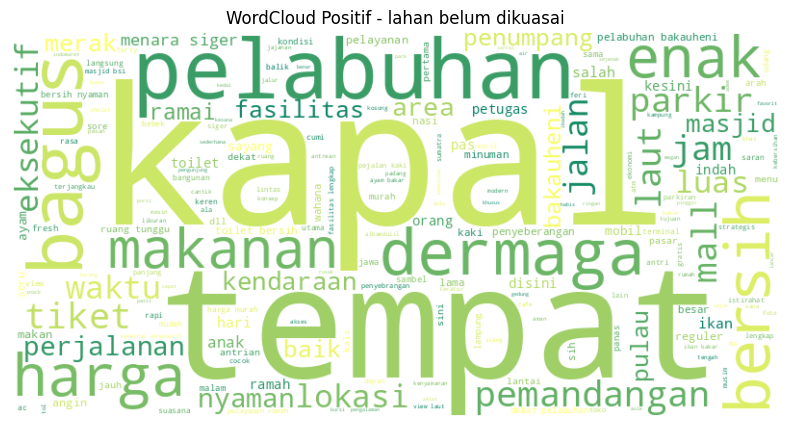

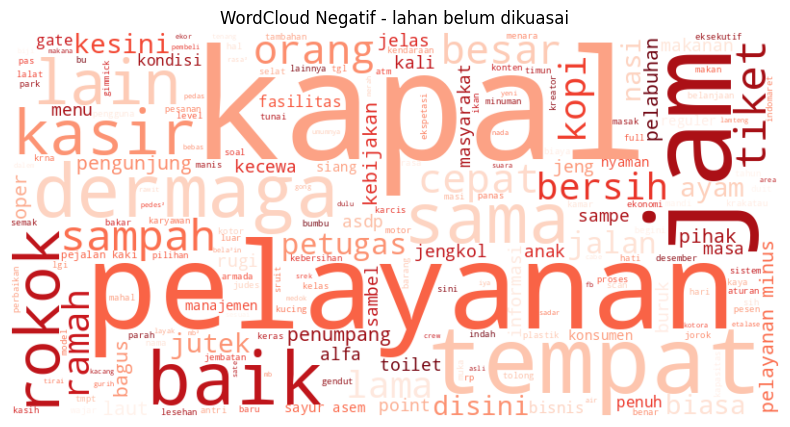

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_wc(sector_name, sentiment_type, color_map):
    # Ambil teks sesuai filter
    text = df_wc_input[(df_wc_input['sector'] == sector_name) &
                       (df_wc_input['sentiment'] == sentiment_type)]['theme'].values

    if len(text) > 0:
        wc = WordCloud(width=800, height=400,
                       background_color='white',
                       colormap=color_map).generate(text[0])

        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f"WordCloud {sentiment_type} - {sector_name}")
        plt.axis("off")
        plt.show()
    else:
        print(f"Tidak ada data untuk {sector_name} - {sentiment_type}")

# CONTOH JALANKAN:
# WordCloud Positif (Warna Hijau/Summer)
generate_wc('lahan belum dikuasai', 'Positif', 'summer')

# WordCloud Negatif (Warna Merah/Reds)
generate_wc('lahan belum dikuasai', 'Negatif', 'Reds')

In [ ]:
# Membuat kolom khusus yang hanya berisi 3 kata teratas
df_wc_input['top_3_keywords'] = df_wc_input['top_words'].apply(lambda x: x[:3])

# Contoh hasil: [(kapal, 26), (pelayanan, 19), (jam, 14)]
display(df_wc_input[['sector', 'sentiment', 'top_3_keywords']])

,sector,sentiment,top_3_keywords
0,lahan belum dikuasai,Negatif,"[(kapal, 26), (pelayanan, 19), (jam, 14)]"
1,lahan belum dikuasai,Netral,"[(pelabuhan, 14), (kapal, 9), (tiket, 6)]"
2,lahan belum dikuasai,Positif,"[(kapal, 89), (pelabuhan, 80), (tempat, 63)]"
3,lahan pemprov,Negatif,"[(nasi, 4), (harga, 3), (mahal, 3)]"
4,lahan pemprov,Netral,"[(direst, 1), (area, 1), (harga, 1)]"
5,lahan pemprov,Positif,"[(jalan, 3), (raya, 2), (bakauheni, 2)]"


## klasifikasi gakepake

```
# klasifikasi
treshold rating 3,5
- rating rendah dan negatif
- rating tinggi dan positif
- rating rendah dan netral
- rating rendah dan positif
```

In [ ]:
def classification(row):
    sentimen = row['sentiment']
    rating = row['rating']

    if sentimen == 'Negatif':
        return 'Evaluasi'
    elif sentimen == 'Netral' and rating < 3.5:
        return 'Evaluasi'
    elif sentimen == 'Positif' and rating < 3.5:
        return 'Evaluasi'
    else:
        return 'Aman'

In [ ]:
df_clean['classification'] = df_clean.apply(classification, axis=1)
df_clean['classification'].value_counts()

,count
classification,
Aman,254
Evaluasi,67


In [ ]:
df_clean.head()

,place_name,rating,text,text_clean,sentiment,score,classification
0,Bebek Mas Mun BakauHeni,5,"Bebeknya enak bgt, bumbunya meresap ke dalam, ...",bebeknya enak banget bumbunya meresap ke dala...,Positif,0.999968,Aman
1,Bebek Mas Mun BakauHeni,5,Bebek enak dan empuk. Bisa dimakan dengan muda...,bebek enak dan empuk bisa dimakan dengan muda...,Positif,0.999970,Aman
2,Bebek Mas Mun BakauHeni,5,Favorit bgt bebek mas mun ... Suka bebeknya ya...,favorit banget bebek mas mun suka bebeknya...,Positif,0.999969,Aman
3,Bebek Mas Mun BakauHeni,5,Makan bebek d sini enak bangett rekomen bebekn...,makan bebek d sini enak bangett rekomen bebekn...,Positif,0.999970,Aman
4,Bebek Mas Mun BakauHeni,5,Mantap ada lalapan ayam terjangkau. Ada harga ...,bagus ada lalapan ayam terjangkau ada harga n...,Positif,0.999957,Aman


In [ ]:
df_clean

,place_name,rating,text,text_clean,sentiment,score,classification
0,Bebek Mas Mun BakauHeni,5,"Bebeknya enak bgt, bumbunya meresap ke dalam, ...",bebeknya enak banget bumbunya meresap ke dala...,Positif,0.999968,Aman
1,Bebek Mas Mun BakauHeni,5,Bebek enak dan empuk. Bisa dimakan dengan muda...,bebek enak dan empuk bisa dimakan dengan muda...,Positif,0.999970,Aman
2,Bebek Mas Mun BakauHeni,5,Favorit bgt bebek mas mun ... Suka bebeknya ya...,favorit banget bebek mas mun suka bebeknya...,Positif,0.999969,Aman
3,Bebek Mas Mun BakauHeni,5,Makan bebek d sini enak bangett rekomen bebekn...,makan bebek d sini enak bangett rekomen bebekn...,Positif,0.999970,Aman
4,Bebek Mas Mun BakauHeni,5,Mantap ada lalapan ayam terjangkau. Ada harga ...,bagus ada lalapan ayam terjangkau ada harga n...,Positif,0.999957,Aman
...,...,...,...,...,...,...,...
316,Wisata Mangrove Bakauheni,5,"Masih alami, kami berkunjung jam 8, jadi masih...",masih alami kami berkunjung jam 8 jadi masih...,Negatif,0.999810,Evaluasi
317,Wisata Mangrove Bakauheni,5,"Masih baru belum terlalu ramai sepertinya,, ra...",masih baru belum terlalu ramai sepertinya ra...,Positif,0.999924,Aman
318,Wisata Mangrove Bakauheni,4,"Belum pernah kesana sih , tp kata teman lokasi...",belum pernah kesana sih tapi kata teman loka...,Positif,0.999960,Aman
319,Wisata Mangrove Bakauheni,4,Tempat wisata ramah lingkungan yg menjaga ekos...,tempat wisata ramah lingkungan yang menjaga ek...,Positif,0.999938,Aman


In [ ]:
df_final = pd.merge(
    df_clean,
    df[['place_name', 'rating', 'text', 'place_lat', 'place_lng', 'reviewer_name', 'time']],
    on=['place_name', 'rating', 'text'],
    how='left'
)

df_final = df_final.drop_duplicates(subset=['text_clean']).reset_index(drop=True)

df_final.head()

,place_name,rating,text,text_clean,sentiment,score,classification,place_lat,place_lng,reviewer_name,time
0,Bebek Mas Mun BakauHeni,5,"Bebeknya enak bgt, bumbunya meresap ke dalam, ...",bebeknya enak banget bumbunya meresap ke dala...,Positif,0.999968,Aman,-5.865811,105.756932,Yunita Qoriyanti,3 minggu lalu
1,Bebek Mas Mun BakauHeni,5,Bebek enak dan empuk. Bisa dimakan dengan muda...,bebek enak dan empuk bisa dimakan dengan muda...,Positif,0.999970,Aman,-5.865811,105.756932,Catherine Puspita,2 tahun lalu
2,Bebek Mas Mun BakauHeni,5,Favorit bgt bebek mas mun ... Suka bebeknya ya...,favorit banget bebek mas mun suka bebeknya...,Positif,0.999969,Aman,-5.865811,105.756932,Ernie Arbie,sebulan lalu
3,Bebek Mas Mun BakauHeni,5,Makan bebek d sini enak bangett rekomen bebekn...,makan bebek d sini enak bangett rekomen bebekn...,Positif,0.999970,Aman,-5.865811,105.756932,Mahfut Arifin,2 bulan lalu
4,Bebek Mas Mun BakauHeni,5,Mantap ada lalapan ayam terjangkau. Ada harga ...,bagus ada lalapan ayam terjangkau ada harga n...,Positif,0.999957,Aman,-5.865811,105.756932,BeWee,3 tahun lalu


In [ ]:
df_final.to_json('df_llm.json', orient='records', indent=4, force_ascii=False)

print("Berhasil menyatukan data!")
print(f"Total baris akhir: {len(df_final)}")
print(df_final.info())

Berhasil menyatukan data!
Total baris akhir: 316
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316 entries, 0 to 315
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   place_name      316 non-null    object 
 1   rating          316 non-null    int64  
 2   text            316 non-null    object 
 3   text_clean      316 non-null    object 
 4   sentiment       316 non-null    object 
 5   score           316 non-null    float64
 6   classification  316 non-null    object 
 7   place_lat       316 non-null    float64
 8   place_lng       316 non-null    float64
 9   reviewer_name   316 non-null    object 
 10  time            316 non-null    object 
dtypes: float64(3), int64(1), object(7)
memory usage: 27.3+ KB
None


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   place_name      321 non-null    object 
 1   rating          321 non-null    int64  
 2   text            321 non-null    object 
 3   text_clean      321 non-null    object 
 4   sentiment       321 non-null    object 
 5   score           321 non-null    float64
 6   classification  321 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 17.7+ KB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   place_name     354 non-null    object 
 1   place_lat      354 non-null    float64
 2   place_lng      354 non-null    float64
 3   reviewer_name  354 non-null    object 
 4   rating         354 non-null    int64  
 5   time           354 non-null    object 
 6   text           354 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 19.5+ KB


In [ ]:
df_clean.to_json('hasil sentiment.json', orient='records', indent=4, force_ascii=False)

print("File JSON sudah siap!")

In [ ]:
# ekstrak masalah
def ekstrak_masalah(row):
    if row['classification'] == 'Evaluasi':
        text = str(row['text_clean']).lower()
        semua_kata = text.split()

        stop_words = {
            'dan', 'yang', 'saya', 'ini', 'itu', 'ada', 'ke', 'banget', 'sudah', 'tapi',
            'karena', 'untuk', 'dengan', 'tempat', 'lokasi', 'sini', 'kalau', 'aja',
            'bgt', 'adalah', 'dari', 'kami', 'kita', 'masih', 'bisa', 'cuma', 'atau',
            'sebenar', 'sebenarnya', 'cukup', 'tadi', 'sangat', 'jadi', 'juga', 'dalam',
            'tidak'
        }

        ignored_words = {'enak', 'nyaman', 'bagus', 'alami', 'indah'}

        kata_penting = [
            kata for kata in semua_kata
            if kata not in stop_words
            and kata not in ignored_words
            and len(kata) > 3
        ]

        hasil = Counter(kata_penting).most_common(8)
        if hasil:
            return ", ".join([k[0] for k in hasil])
        else:
            return " ".join(semua_kata[:5]) + "..."

    return "-"

In [ ]:
df_clean['problem'] = df_clean.apply(ekstrak_masalah, axis=1)
df_clean.head()

,place_name,rating,text,text_clean,sentiment,score,classification,problem
0,Bebek Mas Mun BakauHeni,5,"Bebeknya enak bgt, bumbunya meresap ke dalam, ...",bebeknya enak banget bumbunya meresap ke dala...,Positif,0.999968,Aman,-
1,Bebek Mas Mun BakauHeni,5,Bebek enak dan empuk. Bisa dimakan dengan muda...,bebek enak dan empuk bisa dimakan dengan muda...,Positif,0.999970,Aman,-
2,Bebek Mas Mun BakauHeni,5,Favorit bgt bebek mas mun ... Suka bebeknya ya...,favorit banget bebek mas mun suka bebeknya...,Positif,0.999969,Aman,-
3,Bebek Mas Mun BakauHeni,5,Makan bebek d sini enak bangett rekomen bebekn...,makan bebek d sini enak bangett rekomen bebekn...,Positif,0.999970,Aman,-
4,Bebek Mas Mun BakauHeni,5,Mantap ada lalapan ayam terjangkau. Ada harga ...,bagus ada lalapan ayam terjangkau ada harga n...,Positif,0.999957,Aman,-


In [ ]:
df_clean[df_clean['problem'] != "-"]

,place_name,rating,text,text_clean,sentiment,score,classification,problem
5,Bebek Mas Mun BakauHeni,1,Karyawan nya gak niat jualan....1 jam lebih nu...,karyawan nya tidak niat jualan 1 jam lebih ...,Negatif,0.999872,Evaluasi,"karyawan, niat, jualan, lebih, nunggu, masak, ..."
11,Rumah Makan Indah Raso Bakauheni,5,"Sebenar nya untuk rumah makan nya enak nyaman,...",sebenar nya untuk rumah makan nya enak nyaman ...,Negatif,0.999070,Evaluasi,"rumah, makan, cuman, tukang, parkir, banyak, rese"
14,Rumah Makan Indah Raso Bakauheni,2,Apa pun lauk makan nasi 🍚 nY + es / air minera...,apa pun lauk makan nasi nya es air miner...,Negatif,0.999832,Evaluasi,"lauk, makan, nasi, mineral, sepaket, harga, 35..."
15,Rumah Makan Indah Raso Bakauheni,1,Rasa nya ga enak harga nya mahal nasi 3 es teh...,rasa nya ga enak harga nya mahal nasi 3 es teh...,Negatif,0.999911,Evaluasi,"harga, rasa, mahal, nasi, rebu, gilaaaa"
16,Rumah Makan Indah Raso Bakauheni,1,"Nasi pakai ayam 50.000 gila gak tuh, bikin jel...",nasi pakai ayam 50 000 gila tidak tuh bikin j...,Negatif,0.999950,Evaluasi,"nasi, pakai, ayam, gila, bikin, jelek, nama, p..."
...,...,...,...,...,...,...,...,...
287,Monumen,3,Waktu masuk kesini cuma bisa masuk ke masjid d...,waktu masuk kesini cuma bisa masuk ke masjid d...,Positif,0.999706,Evaluasi,"masuk, masjid, waktu, kesini, petugasnya, bila..."
292,Monumen,1,Saya cukup takjub dengan kemajuan tempat ini d...,saya cukup takjub dengan kemajuan tempat ini d...,Negatif,0.999934,Evaluasi,"tahun, takjub, kemajuan, tiga, terakhir, namun..."
304,Menara Siger Lampung,1,Pengurus kawasan ini gak becus...area parkir d...,pengurus kawasan ini tidak becus area parkir...,Negatif,0.999874,Evaluasi,"parkir, pengurus, kawasan, becus, area, dipaka..."
312,Krakatau Park Lampung,1,⭐☆☆☆☆ (1 bintang)\nSangat merugikan dan mengec...,1 bintang \nsangat merugikan dan mengecewakan ...,Negatif,0.999949,Evaluasi,"tiket, merugikan, kebijakan, konsumen, aturan,..."


In [ ]:
df_clean[['text_clean']]

,text_clean
0,bebeknya enak banget bumbunya meresap ke dala...
1,bebek enak dan empuk bisa dimakan dengan muda...
2,favorit banget bebek mas mun suka bebeknya...
3,makan bebek d sini enak bangett rekomen bebekn...
4,bagus ada lalapan ayam terjangkau ada harga n...
...,...
316,masih alami kami berkunjung jam 8 jadi masih...
317,masih baru belum terlalu ramai sepertinya ra...
318,belum pernah kesana sih tapi kata teman loka...
319,tempat wisata ramah lingkungan yang menjaga ek...


In [ ]:
df_clean.to_csv('hasil_analisis_rapi.csv', sep=';', index=False, encoding='utf-8-sig')

from google.colab import files
files.download('hasil_analisis_rapi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ekstrak masalah
def topik_utama(place_name, dataframe):
    ulasan_negatif = dataframe[(dataframe['place_name'] == place_name) & (dataframe['sentiment'] == 'Negatif')]['text_clean']
    semua_kata = " ".join(ulasan_negatif).split()
    stop_words = {'dan', 'di', 'yang', 'saya', 'ini', 'itu', 'ada', 'ke', 'banget', 'saya', 'toko', 'sudah', 'tapi'}
    kata_penting = [kata for kata in semua_kata if kata not in stop_words and len(kata) > 3]
    masalah_utama = Counter(kata_penting).most_common(3)
    return ", ".join([kata[0] for kata in masalah_utama])

df_clean['problem'] = df_clean['problem'].apply(lambda x: topik_utama(x, df_clean))
df_clean

In [ ]:
def status(row):
    if row['rating_rata_rata'] < 3.5 and row['%_negatif'] > 30:
        return "Kritis"
    if row['%_negatif'] > 40:
        return "Perlu evaluasi"
    return "Good"

summary['rekomendasi_aksi'] = summary.apply(tentukan_status, axis=1)

#summary.to_csv('LAPORAN_PENGEMBANGAN_WILAYAH.csv', index=False)
summary.sort_values(by='%_negatif', ascending=False)

,wilayah,nama_toko,total_ulasan,komplain_negatif,pujian_positif,%_negatif,rekomendasi_aksi
2,Jaksel,Toko Maju,1,1,0,100.00,Kritis
0,Jakbar,Warung Gede,3,2,1,66.67,Kritis
1,Jaksel,Toko Berkah,2,1,1,50.00,Kritis


### agregasi

In [ ]:
# grouping
summary = df_clean.groupby(['place_name']).agg(
    total_ulasan=('sentiment', 'count'),
    rating_rata_rata=('rating', 'mean'),
    komplain_negatif=('sentimen', lambda x: (x == 'NEGATIVE').sum()),
    pujian_positif=('sentimen', lambda x: (x == 'POSITIVE').sum())
).reset_index()

# persentase
summary['%_negatif'] = round((summary['komplain_negatif'] / summary['total_ulasan']) * 100, 2)

In [ ]:
def ekstrak_masalah_toko(nama_toko, dataframe):
    ulasan_negatif = dataframe[(dataframe['nama_toko'] == nama_toko) & (dataframe['sentimen'] == 'NEGATIVE')]['text_clean']
    semua_kata = " ".join(ulasan_negatif).split()
    stop_words = {'dan', 'di', 'yang', 'saya', 'ini', 'itu', 'ada', 'ke', 'banget', 'saya', 'toko', 'sudah', 'tapi'}
    kata_penting = [kata for kata in semua_kata if kata not in stop_words and len(kata) > 3]
    masalah_utama = Counter(kata_penting).most_common(3)
    return ", ".join([kata[0] for kata in masalah_utama])

summary['masalah_utama'] = summary['nama_toko'].apply(lambda x: ekstrak_masalah_toko(x, df))
summary
# Simpan lagi yang ada masalah utamanya
# summary.to_csv('LAPORAN_FINAL_STRATEGIS.csv', index=False)

,wilayah,nama_toko,total_ulasan,komplain_negatif,pujian_positif,%_negatif,rekomendasi_aksi,masalah_utama
0,Jakbar,Warung Gede,3,2,1,66.67,Kritis,"kecewa, parah, antrian"
1,Jaksel,Toko Berkah,2,1,1,50.00,Kritis,"barangnya, jelek, hancur"
2,Jaksel,Toko Maju,1,1,0,100.00,Kritis,"biasa, standar"


### batas

In [ ]:
# ==========================================
# 1. INSTALL & LOAD LIBRARY
# ==========================================


# ==========================================
# 2. KONFIGURASI PIPELINE
# ==========================================
# Ganti dengan nama file kamu (pastikan sudah upload ke folder 'files' di kiri Colab)
FILE_INPUT = 'data_google_maps.csv'
NAMA_KOLOM_ULASAN = 'ulasan' # Ganti sesuai nama kolom di CSV kamu
NAMA_KOLOM_RATING = 'rating' # Ganti sesuai nama kolom di CSV kamu
BATCH_SIZE = 32              # Ukuran tumpukan data (32-64 oke buat GPU T4)

# ==========================================
# 3. FUNGSI PEMBERSIH (NORMALISASI)
# ==========================================
def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    # Kamus singkat (bisa kamu tambah sendiri)
    kamus = {"jlek": "jelek", "bgt": "banget", "ancur": "hancur", "gk": "tidak", "mumer": "murah"}
    for alay, baku in kamus.items():
        text = re.sub(r'\b' + alay + r'\b', baku, text)
    # Hapus simbol/emoji berlebih
    text = re.sub(r'[^\w\s]', ' ', text)
    return text.strip()

# ==========================================
# 4. ENGINE AI (INDOBERT)
# ==========================================
print("⏳ Loading AI Engine...")
device = 0 if torch.cuda.is_available() else -1
classifier = pipeline("text-classification",
                      model="crypter70/IndoBERT-Sentiment-Analysis",
                      device=device)

# ==========================================
# 5. JALANKAN PIPELINE
# ==========================================
def run_pipeline(file_path):
    # a. Load Data
    print("📖 Membaca data...")
    df = pd.read_csv(file_path)

    # b. Cleaning
    print("🧹 Membersihkan teks alay...")
    df['text_clean'] = df[NAMA_KOLOM_ULASAN].apply(clean_text)

    # c. Analisis Sentimen (Massal)
    print(f"🚀 Menganalisis {len(df)} review via GPU...")
    texts = df['text_clean'].tolist()
    results = []

    for out in tqdm(classifier(texts, batch_size=BATCH_SIZE), total=len(texts)):
        results.append(out)

    # d. Mapping Hasil
    mapping = {"LABEL_0": "NEUTRAL", "LABEL_1": "POSITIVE", "LABEL_2": "NEGATIVE",
               "POSITIVE": "POSITIVE", "NEGATIVE": "NEGATIVE", "NEUTRAL": "NEUTRAL"}

    df['sentimen'] = [mapping.get(x['label'].upper(), x['label']) for x in results]
    df['confidence'] = [round(x['score'], 4) for x in results]

    # e. Agregasi & Scoring (Insight buat Bos)
    print("📊 Membuat rangkuman wilayah...")
    summary = df.groupby(['wilayah', 'nama_toko']).agg(
        total_review=('sentimen', 'count'),
        avg_rating=(NAMA_KOLOM_RATING, 'mean'),
        negatif_count=('sentimen', lambda x: (x == 'NEGATIVE').sum()),
        positif_count=('sentimen', lambda x: (x == 'POSITIVE').sum())
    ).reset_index()

    summary['persen_negatif'] = round((summary['negatif_count'] / summary['total_review']) * 100, 2)

    # f. Logic Status
    def get_status(row):
        if row['avg_rating'] < 3 and row['persen_negatif'] > 30: return "🚨 KRITIS"
        if row['persen_negatif'] > 40: return "⚠️ EVALUASI"
        return "✅ OK"

    summary['status_lokasi'] = summary.apply(get_status, axis=1)

    return df, summary

# ==========================================
# EXECUTE!
# ==========================================
# Pastikan file_input ada, atau ganti dengan dummy data yg kita buat tadi
try:
    df_hasil, df_laporan = run_pipeline(FILE_INPUT)
    print("\n✅ PIPELINE SELESAI!")
    print(df_laporan)

    # Simpan Hasil
    df_laporan.to_csv('LAPORAN_FINAL_WILAYAH.csv', index=False)
except Exception as e:
    print(f"❌ Ada masalah: {e}")

In [ ]:
!pip install transformers torch pandas

import pandas as pd
from transformers import pipeline
from google.colab import files
import io

In [ ]:
data = {
    'wilayah': ['Jaksel', 'Jaksel', 'Jaksel', 'Jakbar', 'Jakbar', 'Jakbar'],
    'nama_toko': ['Toko Berkah', 'Toko Berkah', 'Toko Maju', 'Warung Gede', 'Warung Gede', 'Warung Gede'],
    'rating': [1, 5, 3, 1, 5, 2], # Rating asli dari Google Maps
    'ulasan': [
        "barangnya jlek bgt, ancur pas sampe!!",
        "adminnya ramah, fast respon bgt pokoknya",
        "biasa aja sih, standar lah",
        "kecewa parah, antrian lama bgt kayak ular",
        "harganya mumer tapi kualitas ori",
        "parkir susah bgt, mana tukang parkirnya galak"
    ]
}
df = pd.DataFrame(data)

In [ ]:
df

,wilayah,nama_toko,rating,ulasan
0,Jaksel,Toko Berkah,1,"barangnya jlek bgt, ancur pas sampe!!"
1,Jaksel,Toko Berkah,5,"adminnya ramah, fast respon bgt pokoknya"
2,Jaksel,Toko Maju,3,"biasa aja sih, standar lah"
3,Jakbar,Warung Gede,1,"kecewa parah, antrian lama bgt kayak ular"
4,Jakbar,Warung Gede,5,harganya mumer tapi kualitas ori
5,Jakbar,Warung Gede,2,"parkir susah bgt, mana tukang parkirnya galak"


In [ ]:
print("⏳ Lagi loading IndoBERT... (Pake GPU biar ngebut)")
# Pake device=0 biar jalan di GPU
classifier = pipeline("text-classification", model="crypter70/IndoBERT-Sentiment-Analysis", device=0)

def normalisasi_teks(teks):
    teks = teks.lower()
    kamus = {
        "jlek": "jelek", "bgt": "banget", "ancur": "hancur",
        "gk": "tidak", "ga": "tidak", "mumer": "murah", "ori": "asli"
    }
    for alay, baku in kamus.items():
        teks = re.sub(r'\b' + alay + r'\b', baku, teks)
    return teks

⏳ Lagi loading IndoBERT... (Pake GPU biar ngebut)


Device set to use cuda:0


In [ ]:
import re
print("🚀 Memulai analisis sentimen...")

# Load data
#df = pd.read_csv('data_google_maps.csv')

# Bersihkan teks
df['ulasan_bersih'] = df['ulasan'].apply(normalisasi_teks)

# Jalankan AI (Batch Processing)
texts = df['ulasan_bersih'].tolist()
hasil_ai = classifier(texts, batch_size=32)

🚀 Memulai analisis sentimen...


In [ ]:
mapping = {"LABEL_0": "NETRAL", "LABEL_1": "POSITIF", "LABEL_2": "NEGATIF"}
df['sentimen'] = [mapping.get(x['label'], x['label']) for x in hasil_ai]
df['skor_yakin'] = [round(x['score'] * 100, 2) for x in hasil_ai]

In [ ]:
# 1. Pastikan kolom 'sentimen' sudah dibuat dari hasil AI
# (Asumsinya kamu sudah running 'hasil_ai = classifier(...)')

if 'hasil_ai' in locals():
    # Mapping label AI ke teks (Sesuaikan dengan hasil DEBUG MENTAH kamu)
    # Kalau modelnya crypter70 biasanya: LABEL_0, LABEL_1, LABEL_2
    # Kalau modelnya Roberto biasanya: POSITIVE, NEGATIVE, NEUTRAL
    mapping = {"LABEL_0": "NEUTRAL", "LABEL_1": "POSITIVE", "LABEL_2": "NEGATIVE",
               "POSITIVE": "POSITIVE", "NEGATIVE": "NEGATIVE", "NEUTRAL": "NEUTRAL"}

    df['sentimen'] = [mapping.get(x['label'].upper(), x['label']) for x in hasil_ai]
    print("✅ Kolom 'sentimen' berhasil ditambahkan!")
else:
    print("❌ Error: Kamu belum running proses AI-nya!")

# 2. Baru jalankan Agregasi
print("\n📊 MENGHITUNG RANGKUMAN DENGAN RATING...")

# Pastikan semua kolom yang dipanggil ada di df
summary = df.groupby(['wilayah', 'nama_toko']).agg(
    total_review=('ulasan', 'count'),
    rata_rata_bintang=('rating', 'mean'),
    # Gunakan 'sentimen' yang barusan kita buat di atas
    jumlah_negatif=('sentimen', lambda x: (x == 'NEGATIVE').sum()),
    jumlah_positif=('sentimen', lambda x: (x == 'POSITIVE').sum())
).reset_index()

# Hitung % Negatif
summary['persen_negatif'] = round((summary['jumlah_negatif'] / summary['total_review']) * 100, 2)

# Tampilkan hasil
print(summary)

✅ Kolom 'sentimen' berhasil ditambahkan!

📊 MENGHITUNG RANGKUMAN DENGAN RATING...
  wilayah    nama_toko  total_review  rata_rata_bintang  jumlah_negatif  \
0  Jakbar  Warung Gede             3           2.666667               2   
1  Jaksel  Toko Berkah             2           3.000000               1   
2  Jaksel    Toko Maju             1           3.000000               1   

   jumlah_positif  persen_negatif  
0               1           66.67  
1               1           50.00  
2               0          100.00  


In [ ]:
def kasih_saran(row):
    if row['persen_negatif'] > 40: return "🔴 PERBAIKAN SEGERA!"
    elif row['persen_negatif'] > 20: return "🟡 Pantau Lokasi"
    else: return "🟢 Aman / Bagus"

summary['rekomendasi'] = summary.apply(kasih_saran, axis=1)

In [ ]:
print("\n--- HASIL ANALISIS TIAP BARIS ---")
print(df[['nama_toko', 'ulasan', 'sentimen', 'skor_yakin']].head())

print("\n--- LAPORAN RANGKUMAN WILAYAH (UNTUK BOS) ---")
print(summary.sort_values(by='persen_negatif', ascending=False))


--- HASIL ANALISIS TIAP BARIS ---
     nama_toko                                     ulasan  sentimen  \
0  Toko Berkah      barangnya jlek bgt, ancur pas sampe!!  NEGATIVE   
1  Toko Berkah   adminnya ramah, fast respon bgt pokoknya  POSITIVE   
2    Toko Maju                 biasa aja sih, standar lah  NEGATIVE   
3  Warung Gede  kecewa parah, antrian lama bgt kayak ular  NEGATIVE   
4  Warung Gede           harganya mumer tapi kualitas ori  POSITIVE   

   skor_yakin  
0      100.00  
1       99.99  
2       99.99  
3      100.00  
4       99.95  

--- LAPORAN RANGKUMAN WILAYAH (UNTUK BOS) ---
  wilayah    nama_toko  total_review  jumlah_negatif  jumlah_positif  \
2  Jaksel    Toko Maju             1               1               0   
0  Jakbar  Warung Gede             3               2               1   
1  Jaksel  Toko Berkah             2               1               1   

   persen_negatif          rekomendasi  
2          100.00  🔴 PERBAIKAN SEGERA!  
0           66.67  🔴 PER

In [ ]:
print("Lagi siap-siap... Model 'crypter70' lagi dipasang.")
classifier = pipeline("text-classification", model="crypter70/IndoBERT-Sentiment-Analysis")

# Mapping biar hasilnya bukan LABEL_0 tapi bahasa manusia
mapping = {
    "LABEL_0": "NETRAL 😐",
    "LABEL_1": "POSITIF 😊",
    "LABEL_2": "NEGATIF 😡"
}

def tes_sentimen(kalimat):
    hasil = classifier(kalimat)[0]
    label_asli = hasil['label']
    score = hasil['score']
    print(f"Teks: {kalimat}")
    print(f"Hasil: {mapping.get(label_asli)} (Keyakinan: {score:.2%})")
    print("-" * 30)

Lagi siap-siap... Model 'crypter70' lagi dipasang.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
def tes_sentimen(kalimat):
    hasil = classifier(kalimat)[0]
    # Kita print mentahannya biar ketahuan label aslinya apa
    print(f"DEBUG MENTAH: {hasil}")

    label_asli = hasil['label']
    score = hasil['score']

    # Mapping baru yang lebih aman
    mapping_baru = {
        "neutral": "NETRAL 😐",
        "positive": "POSITIF 😊",
        "negative": "NEGATIF 😡"
    }

    # Pake .get() dengan default value biar gak 'None' lagi
    kesimpulan = mapping_baru.get(label_asli.lower(), label_asli)

    print(f"Teks: {kalimat}")
    print(f"Hasil Akhir: {kesimpulan} (Keyakinan: {score:.2%})")
    print("-" * 30)

# Tes lagi
tes_sentimen("Barangnya sampai dengan selamat, adminnya fast respon!")

DEBUG MENTAH: {'label': 'POSITIVE', 'score': 0.9999434947967529}
Teks: Barangnya sampai dengan selamat, adminnya fast respon!
Hasil Akhir: POSITIF 😊 (Keyakinan: 99.99%)
------------------------------


In [ ]:
# --- COBA MASUKIN TEKS SESUKA HATI DI SINI ---
tes_sentimen("Seneng banget nih barangnya ancur")
tes_sentimen("Lama banget pengirimannya, kapok belanja di sini.")
tes_sentimen("Biasa aja sih, kualitas sesuai harga.")

DEBUG MENTAH: {'label': 'POSITIVE', 'score': 0.9998923540115356}
Teks: Seneng banget nih barangnya ancur
Hasil Akhir: POSITIF 😊 (Keyakinan: 99.99%)
------------------------------
DEBUG MENTAH: {'label': 'NEGATIVE', 'score': 0.9999520778656006}
Teks: Lama banget pengirimannya, kapok belanja di sini.
Hasil Akhir: NEGATIF 😡 (Keyakinan: 100.00%)
------------------------------
DEBUG MENTAH: {'label': 'NEGATIVE', 'score': 0.9594191312789917}
Teks: Biasa aja sih, kualitas sesuai harga.
Hasil Akhir: NEGATIF 😡 (Keyakinan: 95.94%)
------------------------------


In [ ]:
from transformers import pipeline

# 1. Panggil RoBERTa (Nama panggilannya Roberto biar akrab)
print("Lagi jemput Roberto (Indonesian RoBERTa)...")
roberto = pipeline("text-classification", model="w11wo/indonesian-roberta-base-sentiment-classifier")

def tes_roberto(kalimat):
    hasil = roberto(kalimat)[0]
    label = hasil['label'].upper() # Biasanya: positive, neutral, negative
    score = hasil['score']

    print(f"Teks: {kalimat}")
    print(f"Hasil Roberto: {label} (Keyakinan: {score:.2%})")
    print("-" * 30)

# 2. Tes kalimat sarkas tadi
tes_roberto("Seneng banget nih barangnya ancur")

# 3. Tes kalimat negatif jujur
tes_roberto("Barangnya ancur parah, kecewa banget!")

Lagi jemput Roberto (Indonesian RoBERTa)...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu


Teks: Seneng banget nih barangnya ancur
Hasil Roberto: POSITIVE (Keyakinan: 76.78%)
------------------------------
Teks: Barangnya ancur parah, kecewa banget!
Hasil Roberto: NEGATIVE (Keyakinan: 99.94%)
------------------------------


In [ ]:
tes_roberto("jlek bgt")

Teks: jlek bgt
Hasil Roberto: POSITIVE (Keyakinan: 96.18%)
------------------------------
